<a href="https://colab.research.google.com/github/soumyaa-physics/ML/blob/main/Computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

for the computer a image is a 3D array of numbers: pixel width x pixel length x3 (the three color channels: RGB)

One of the ways for the machine to learn what is an image, is by using a training set. - this is called data driven approach.

Input: training set

Learning: train the machine with the training set -> called training a classifier

Evaluation: using a new set to validate

***Nearest Neighbor Classification:***

calculate the difference between two pixels (pixels at the same  (x,y)) of two images:

L1 distance (also known as the Manhattan distance) between two images and the number in the matris is the RGB value (0 to 255), so instead of having single value in each matrix element it will be like(0,0,255), (192,192,192), and so on.


In [ ]:
import numpy as np

formula = r"d1(I1, I2) = \sum_p |I1^p - I2^p|"
print(formula)

# Define the matrices for the two images
I1 = np.array([
    [10, 20, 30],
    [40, 50, 60],
    [70, 80, 90]
])

I2 = np.array([
    [5, 25, 35],
    [45, 55, 65],
    [75, 85, 95]
])

# Compute the absolute differences between corresponding pixels
absolute_differences = np.abs(I1 - I2)

# Compute the L1 distance (sum of all absolute differences)
l1_distance = np.sum(absolute_differences)

# Print results
print("Absolute Differences Matrix:")
print(absolute_differences)
print("\nL1 Distance:", l1_distance)


d1(I1, I2) = \sum_p |I1^p - I2^p|
Absolute Differences Matrix:
[[5 5 5]
 [5 5 5]
 [5 5 5]]

L1 Distance: 45


In [ ]:
!wget -P data/ https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!tar -xvzf data/cifar-10-python.tar.gz -C data/
#!ls data/cifar-10-batches-py

--2025-01-13 14:53:40--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘data/cifar-10-python.tar.gz.5’

cifar-10-python.tar 100%[===================>] 162.60M  13.9MB/s    in 14s     

2025-01-13 14:53:54 (12.0 MB/s) - ‘data/cifar-10-python.tar.gz.5’ saved [170498071/170498071]

cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


In [ ]:
import pickle
import os
import numpy as np

data_dir = 'data/cifar-10-batches-py/'

def load_CIFAR10(data_dir):
    def load_batch(file):
        print(f"Trying to open file: {file}")  # Add this to debug
        with open(file, 'rb') as f:
            data_dict = pickle.load(f, encoding='bytes')
            data = data_dict[b'data']
            labels = data_dict[b'labels']
            return data, labels

    X_train, Y_train = [], []
    for i in range(1, 6):
        file = os.path.join(data_dir, f"data_batch_{i}")
        print(f"Loading batch file: {file}")  # Debug the file path
        if not os.path.exists(file):
            raise FileNotFoundError(f"File {file} not found!")
        data, labels = load_batch(file)
        X_train.append(data)
        Y_train.extend(labels)

    X_train = np.concatenate(X_train)
    Y_train = np.array(Y_train)

    test_file = os.path.join(data_dir, "test_batch")
    print(f"Loading test file: {test_file}")  # Debug the test batch file path
    if not os.path.exists(test_file):
        raise FileNotFoundError(f"Test file {test_file} not found!")
    X_test, Y_test = load_batch(test_file)

    X_test = np.array(X_test)
    Y_test = np.array(Y_test)

    return X_train, Y_train, X_test, Y_test

print(os.getcwd())  # Current working directory
print(os.listdir('data/cifar-10-batches-py'))  # List contents of the dataset directory
X_train, Y_train, X_test, Y_test = load_CIFAR10(data_dir)
print("Shape of X_test", {X_test.shape})  # Should be (10000, 3072)
print("Shape of Y_test", {Y_test.shape})  # Should be (10000,)


/content
['data_batch_5', 'data_batch_3', 'test_batch', 'data_batch_1', 'data_batch_2', 'data_batch_4', 'batches.meta', 'readme.html']
Loading batch file: data/cifar-10-batches-py/data_batch_1
Trying to open file: data/cifar-10-batches-py/data_batch_1
Loading batch file: data/cifar-10-batches-py/data_batch_2
Trying to open file: data/cifar-10-batches-py/data_batch_2
Loading batch file: data/cifar-10-batches-py/data_batch_3
Trying to open file: data/cifar-10-batches-py/data_batch_3
Loading batch file: data/cifar-10-batches-py/data_batch_4
Trying to open file: data/cifar-10-batches-py/data_batch_4
Loading batch file: data/cifar-10-batches-py/data_batch_5
Trying to open file: data/cifar-10-batches-py/data_batch_5
Loading test file: data/cifar-10-batches-py/test_batch
Trying to open file: data/cifar-10-batches-py/test_batch
Shape of X_test {(10000, 3072)}
Shape of Y_test {(10000,)}


In [ ]:
data_dir = 'data/cifar-10-batches-py/'
Xtr, Ytr, Xte, Yte = load_CIFAR10(data_dir) # a magic function we provide
# flatten out all images to be one-dimensional
Xtr = Xtr.reshape(Xtr.shape[0], 32 * 32 * 3) # Xtr_rows becomes 50000 x 3072 TRAINING SET
Xtr_rows =  Xtr[:40000] #validation set of 10k entries
Ytr_rows = Ytr[:40000]
Xvalidation = Xtr[40000:50000] # Xtr_rows becomes 40000 x 3072 TRAINING SET
Yvalidation = Ytr[40000:50000]

print("Shape of X_validation", {Xvalidation.shape})  # Should be (10000, 3072)
print("Shape of Y_validation", {Yvalidation.shape})  # Should be (10000,)
Xte_rows = Xte.reshape(Xte.shape[0], 32 * 32 * 3) # Xte_rows becomes 10000 x 3072 EVALUATION SET

Loading batch file: data/cifar-10-batches-py/data_batch_1
Trying to open file: data/cifar-10-batches-py/data_batch_1
Loading batch file: data/cifar-10-batches-py/data_batch_2
Trying to open file: data/cifar-10-batches-py/data_batch_2
Loading batch file: data/cifar-10-batches-py/data_batch_3
Trying to open file: data/cifar-10-batches-py/data_batch_3
Loading batch file: data/cifar-10-batches-py/data_batch_4
Trying to open file: data/cifar-10-batches-py/data_batch_4
Loading batch file: data/cifar-10-batches-py/data_batch_5
Trying to open file: data/cifar-10-batches-py/data_batch_5
Loading test file: data/cifar-10-batches-py/test_batch
Trying to open file: data/cifar-10-batches-py/test_batch
Shape of X_validation {(10000, 3072)}
Shape of Y_validation {(10000,)}


In [ ]:
!pip install torch torchvision torchaudio

In [ ]:
!pip install faiss-gpu

Validation Accuracy for k=2: 0.300
Validation Accuracy for k=4: 0.324
Validation Accuracy for k=8: 0.323
Validation Accuracy for k=14: 0.321
Validation Accuracy for k=25: 0.313
Validation Accuracy for k=57: 0.303
Validation Accuracy for k=101: 0.294
Test Accuracy for k=2: 0.305
Test Accuracy for k=4: 0.333
Test Accuracy for k=8: 0.337
Test Accuracy for k=14: 0.338
Test Accuracy for k=25: 0.330
Test Accuracy for k=57: 0.317
Test Accuracy for k=101: 0.306


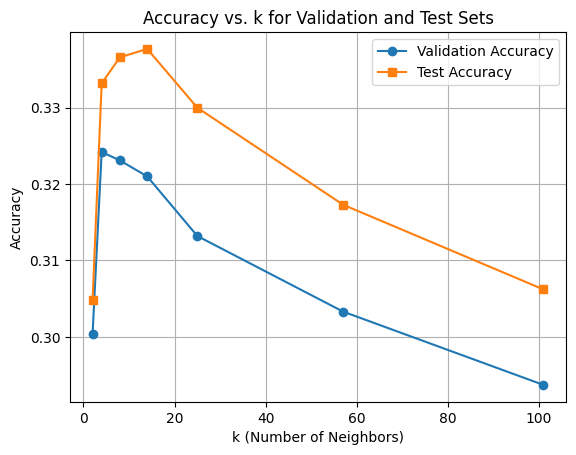

In [ ]:
import numpy as np
import faiss

class NearestNeighborFAISS:
    def __init__(self):
        self.index = None
        self.ytr = None

    def train(self, X, y):
        """
        Train the nearest neighbor classifier.
        X: Training data of shape (M, D)
        y: Training labels of shape (M,)
        """
        self.ytr = y
        d = X.shape[1]  # Dimensionality of feature space
        self.index = faiss.IndexFlatL2(d)  # Create an L2 distance FAISS index
        #the above finds the nearest distance of the X vector and stores it

        self.index = faiss.index_cpu_to_gpu(faiss.StandardGpuResources(), 0, self.index)
        self.index.add(X.astype(np.float32))
        # Add training data to the index

    def predict(self, X, k=k):
        """
        Predict the labels for the test dataset.
        X: Test data of shape (N, D)
        k: Number of nearest neighbors to consider
        Returns: Predicted labels of shape (N,)
        """
        distances, indices = self.index.search(X.astype(np.float32), k)
        if k == 1:
            return self.ytr[indices.flatten()]  # Return nearest neighbor labels
        else:
            return np.array([np.bincount(self.ytr[indices[i]]).argmax() for i in range(indices.shape[0])])

import matplotlib.pyplot as plt


# Train and evaluate the Nearest Neighbor FAISS classifier
k_values = [2, 4, 8, 14, 25, 57, 101]
validation_accuracies = []
test_accuracies = []

for k in k_values:
    # Train on training data (Xtr_rows)
    nn = NearestNeighborFAISS()
    nn.train(Xtr_rows, Ytr_rows)

    # Predict labels for the validation set
    Ypred = nn.predict(Xvalidation, k=k) #EXPLICITLY WRITE K HERE AS WELL
    accuracy = np.mean(Ypred == Yvalidation)
    print(f"Validation Accuracy for k={k}: {accuracy:.3f}")
    validation_accuracies.append(accuracy)
# Predict on the test set (Xte_rows) using the best k from validation
for k in k_values:
    # Train on the full training data (Xtr_rows)
    nn = NearestNeighborFAISS()
    nn.train(Xtr_rows, Ytr_rows)

    # Predict labels for the test set
    Yprediction = nn.predict(Xte_rows, k=k)
    accuracy1 = np.mean(Yprediction == Yte)
    test_accuracies.append(accuracy1)
    print(f"Test Accuracy for k={k}: {accuracy1:.3f}")

plt.plot(k_values, validation_accuracies, label="Validation Accuracy", marker='o')
plt.plot(k_values, test_accuracies, label="Test Accuracy", marker='s')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. k for Validation and Test Sets")
plt.legend()
plt.grid(True)
plt.show()